# Decision Tree

# 1. What is a Decision Tree?

A **Decision Tree** is a supervised Machine Learning algorithm used for both **Classification** and **Regression** problems.

It works like a flowchart where every internal node represents a decision based on a feature, every branch represents the outcome of that decision, and every leaf node represents the final prediction.

The model asks a series of simple questions and gradually reaches the final answer.

## Example

Suppose we want to classify fruits.

We have three features:

- Fruit Size (Small, Medium, Large)
- Fruit Color (Red, Green)
- Fruit Name (Apple, Grape, Watermelon)

The Decision Tree first finds the feature that best separates the data.

For example:

- Is the fruit Red?
    - Yes → Go to the left branch.
    - No → Go to the right branch.

The process continues until the model reaches a leaf node, which gives the final prediction.

# 2. How Does a Decision Tree Work?

A Decision Tree works in four main steps.

### Step 1

Select the best feature for splitting the dataset.

### Step 2

Split the dataset into smaller groups.

### Step 3

Repeat the process on every branch.

### Step 4

Stop when all records belong to one class or another stopping condition is reached.

The final node is called the **Leaf Node**, which contains the prediction.

# 3. Entropy

Entropy is a measure of **uncertainty** or **randomness** in the dataset.

It tells us how mixed the classes are.

- Low Entropy → Less confusion
- High Entropy → More confusion

Decision Trees try to reduce entropy after every split.

## Entropy Examples

### Basket 1

- 10 Apples
- 0 Oranges

Entropy = **0**

There is no confusion because every fruit belongs to the same class.

### Basket 2

- 5 Apples
- 5 Oranges

Entropy is Maximum.

The dataset is completely mixed.

## Entropy Formula

$$
Entropy = -\sum P_i \log_2(P_i)
$$
Where:

- $(P_i)$ = Probability of each class.

## Example Calculation

Suppose we have:

- 4 Apples
- 6 Oranges

Then,

- P(Apple) = 4/10
- P(Orange) = 6/10

The entropy becomes approximately

$
Entropy \approx 0.97
$

A higher entropy means the data is more mixed and needs further splitting.

# 4. Gini Impurity

Gini Impurity measures the probability of making an incorrect classification.

Lower Gini means a better split.

Many Decision Tree algorithms use Gini instead of Entropy because it is computationally faster.

## Gini Formula

$
Gini = 1 - \sum P_i^2
$

Where:

- $(P_i^2)$ is the probability of each class.

## Example

Suppose:

- P(Apple) = 0.4
- P(Orange) = 0.6

Then,

$
Gini = 1 - (0.4^2 + 0.6^2)
$

$
= 1 - (0.16 + 0.36)
$

$
= 0.48
$

A lower Gini value indicates a purer split.

# 5. Information Gain

Information Gain measures how much uncertainty is reduced after splitting the dataset.

Decision Trees always choose the split with the **highest Information Gain**.

## Information Gain Formula

$$
IG = Entropy(\text{Parent}) - Weighted\ Entropy(\text{Children})
$$

## Example

Suppose the parent dataset contains:

- 8 Apples
- 2 Oranges

**Parent Entropy = 0.72**

After splitting:

### Group 1

- 6 Apples
- 0 Oranges

**Entropy = 0**

### Group 2

- 2 Apples
- 2 Oranges

**Entropy = 1**

### Weighted Entropy

$$
Weighted\ Entropy
=
\frac{6}{10}(0)
+
\frac{4}{10}(1)
=
0.4
$$

### Information Gain

$$
IG
=
0.72
-
0.4
=
0.32
$$

**Higher Information Gain means a better split.**

# 6. Geometric Intuition

Imagine a graph with:

- X-axis → Fruit Size
- Y-axis → Fruit Color

A Decision Tree separates the data by drawing vertical and horizontal decision boundaries.

Each region represents one class.

The model keeps dividing the space until each region contains mostly one class.

# 7. Python Implementation

In [1]:
# Import Libraries

import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [2]:
# Create Dataset
data = {
    "Size":["Small", "Small", "Medium", "Large", "Large"],
    "Color":["Red", "Green", "Red", "Green", "Red"],
    "Fruit":["Apple", "Grape", "Apple", "Watermelon", "Watermelon"]
}

In [3]:
# Convert dictionary into DataFrame
df = pd.DataFrame(data)

In [4]:
# Convert categorical values into numbers

df["Size"] = df["Size"].map({"Small":0,"Medium":1,"Large":2})

df["Color"] = df["Color"].map({"Red":0,"Green":1})

In [5]:
# Separate features and target

x = df[["Size","Color"]]
y = df["Fruit"]

In [6]:
# Create Decision Tree model

tree = DecisionTreeClassifier(criterion="entropy", random_state=42)


In [7]:
# Train the model

tree.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

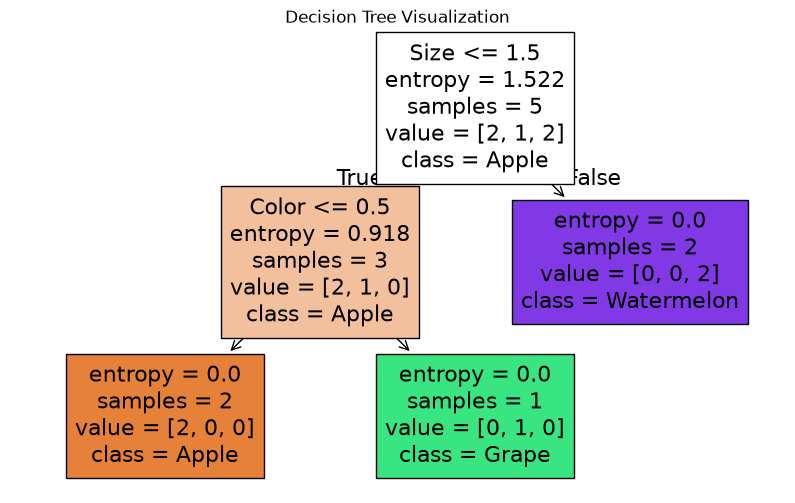

Prediction: ['Apple']


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [8]:
# Visualize the tree

plt.figure(figsize=(10,6))

plot_tree(tree, feature_names=["Size","Color"], class_names=tree.classes_,filled=True)

plt.title("Decision Tree Visualization")

plt.show()

# Predict a new sample

prediction = tree.predict([[1,0]])
print("Prediction:", prediction)

# Decision Tree with Categorical and Numerical Features

Decision Trees are Machine Learning algorithms that can work with both **categorical** and **numerical** features.

A Decision Tree follows a **tree-like structure** where:

- Internal Nodes represent features.
- Branches represent decisions or conditions.
- Leaf Nodes represent the final prediction.

In this section, we will learn how Decision Trees work with:

1. Categorical Features
2. Numerical Features
3. Mixed Features (Categorical + Numerical)

# 1. Decision Tree with Categorical Features

## What are Categorical Features?

Categorical features contain a fixed number of categories or labels.

Examples:

- Color → Red, Green, Yellow
- Shape → Round, Long
- Gender → Male, Female

Decision Trees analyze these categories and split the dataset based on the most informative feature.

## Example Problem

### Input Features

- Color
- Shape

### Target Variable

Fruit Type

- Apple
- Banana
- Cucumber

The Decision Tree will predict the fruit based on its color and shape.

## How Decision Trees Split Categorical Features

### Step 1

Find all unique categories of each feature.

Example

Color

- Red
- Yellow
- Green

Shape

- Round
- Long

### Step 2

The Decision Tree creates branches for each category.

Example

Color = Red

↓

Apple

or

Shape = Long

↓

Banana or Cucumber

The feature that provides the best split is selected first.

## Categorical Features Code Example

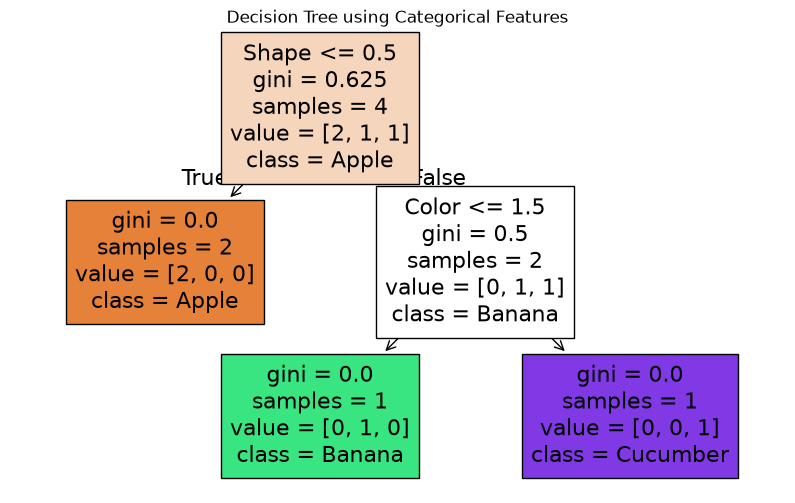

Prediction: [0]


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [10]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Dataset

data = {
    'Color': ['Red', 'Yellow', 'Green', 'Green'],
    'Shape': ['Round', 'Long', 'Round', 'Long'],
    'Fruit': ['Apple', 'Banana', 'Apple', 'Cucumber']
}

df = pd.DataFrame(data)

# Encode categorical variables

df['Color'] = df['Color'].map({'Red':0, 'Yellow':1,'Green':2 })

df['Shape'] = df['Shape'].map({'Round':0, 'Long':1})

df["Fruit"] = df['Fruit'].map({'Apple':0, 'Banana':1, 'Cucumber':2})


x = df[['Color','Shape']]
y = df['Fruit']

tree = DecisionTreeClassifier(criterion="gini",random_state=42)

tree.fit(x,y)

plt.figure(figsize=(10,6))

plot_tree(tree, feature_names=['Color','Shape'], class_names=['Apple','Banana','Cucumber'], filled=True)

plt.title("Decision Tree using Categorical Features")
plt.show()

prediction = tree.predict([[0,0]])
print("Prediction:", prediction)

## Code Explanation

### Dataset

Color and Shape are the input features.

Fruit is the target variable.

### Encoding

Since Decision Trees cannot directly process text values, all categories are converted into numerical values.

### Model Training

The DecisionTreeClassifier() is used to train the model.

The **Gini Impurity** criterion is used to select the best split.

### Visualization

The plot_tree() function displays the complete Decision Tree.

### Prediction

Input

- Color = Red
- Shape = Round

Predicted Output

Apple

## Expected Output

Prediction

Apple

Visualization

A Decision Tree showing:

- Root Node
- Internal Nodes
- Leaf Nodes

with different colors representing different classes.

# 2. Decision Tree with Numerical Features

## What are Numerical Features?

Numerical features contain continuous numerical values.

Examples

- Age
- Salary
- Height
- Weight
- Income

Decision Trees split numerical features using threshold values.

Examples

Age ≤ 30

Salary > 50000

## Example Problem

### Input Features

- Age
- Salary

### Target Variable

Loan Approval

- Yes
- No

## How Decision Trees Split Numerical Features

Decision Trees evaluate different threshold values.

Example

Age values

25

30

35

40

Possible splits

Age ≤ 30

Age ≤ 35

Age ≤ 40

The threshold that produces the best split is selected.

## Numerical Features Code Example

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [13]:
data = {
    "Age":[25,30,35,40],
    "Salary":[50000,60000,70000,40000],
    "Loan_Approved":['No','Yes','Yes','No']
}

df = pd.DataFrame(data)

In [14]:
df['Loan_Approved']=df['Loan_Approved'].map({'No':0, 'Yes':1})

x=df[['Age','Salary']]
y=df['Loan_Approved']

In [15]:
tree = DecisionTreeClassifier(criterion="gini", random_state=42)

tree.fit(x,y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

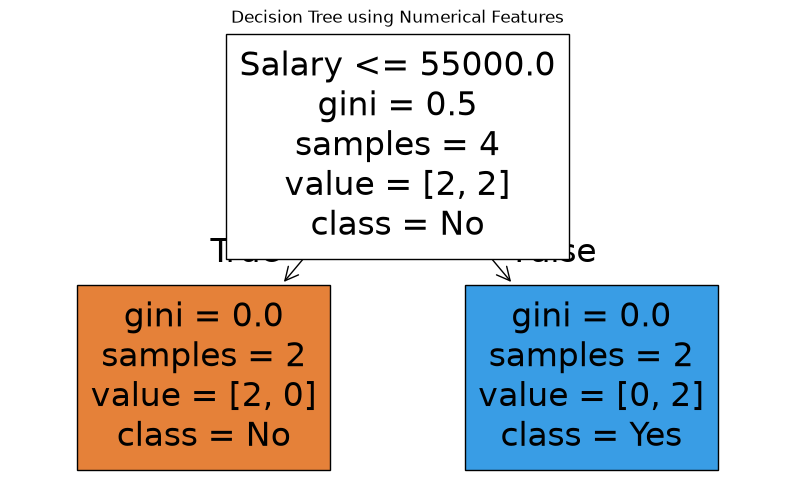

Prediction: [0]


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [16]:
plt.figure(figsize=(10,6))

plot_tree(tree,feature_names=["Age","Salary"], class_names=["No","Yes"], filled=True)

plt.title("Decision Tree using Numerical Features")
plt.show()

prediction = tree.predict([[28,45000]])
print("Prediction:",prediction)

## Code Explanation

### Dataset

Age and Salary are the input features.

Loan Approval is the target variable.

### Threshold Splitting

The Decision Tree automatically finds the best threshold values.

Examples

Age ≤ 30

Salary ≤ 55000

### Prediction

Input

Age = 28

Salary = 45000

Predicted Output

No

## Expected Output

Prediction

No

Visualization

The Decision Tree splits the data using threshold values for Age and Salary.

# 3. Decision Tree with Mixed Features

## What are Mixed Features?

Mixed datasets contain both:

- Numerical Features
- Categorical Features

Decision Trees automatically handle both types without additional complexity.

## Example Problem

### Input Features

- Age
- Gender

### Target Variable

Bought Car

- Yes
- No

## How Decision Trees Handle Mixed Features

### Numerical Features

The tree creates threshold-based splits.

Example

Age ≤ 30

### Categorical Features

The tree creates category-based branches.

Example

Gender

- Male
- Female

The algorithm automatically selects the feature that provides the best split.

## Mixed Features Code Example

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

data = {
    'Age':[25,30,35,40],
    'Gender':['Male','Female','Male','Female'],
    'Bought_Car':['No','Yes','Yes','No']
}

df = pd.DataFrame(data)

df["Gender"] = df["Gender"].map({"Male":0, "Female":1})

df['Bought_Car'] = df['Bought_Car'].map({"No":0, "Yes":1})

x=df[['Age','Gender']]
y=df['Bought_Car']

tree = DecisionTreeClassifier(criterion="gini", random_state=42)

tree.fit(x,y)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

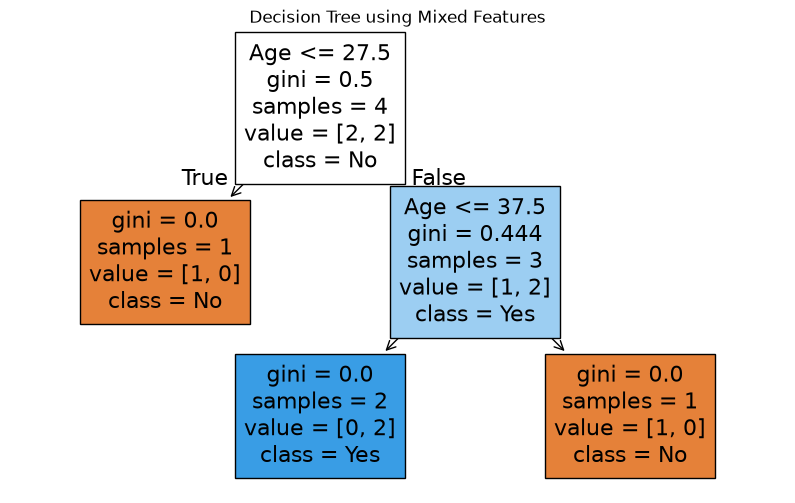

Prediction: [1]


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [18]:
plt.figure(figsize=(10,6))

plot_tree(tree, feature_names=['Age','Gender'], class_names=['No','Yes'], filled=True)

plt.title("Decision Tree using Mixed Features")
plt.show()

prediction=tree.predict([[28,1]])
print("Prediction:",prediction)

## Code Explanation

### Dataset

Age is a numerical feature.

Gender is a categorical feature.

Bought Car is the target variable.

### Model Training

The Decision Tree automatically:

- Creates threshold splits for numerical features.
- Creates category-based splits for categorical features.

### Prediction

Input

Age = 28

Gender = Female

Predicted Output

Yes

## Expected Output

Prediction

Yes

Visualization

The Decision Tree uses both numerical and categorical features to make the final prediction.

# Summary

| Feature Type | Splitting Method | Example |
|--------------|------------------|---------|
| Categorical Features | Split by unique categories | Color → Red, Green |
| Numerical Features | Split using threshold values | Age ≤ 30 |
| Mixed Features | Combination of thresholds and categories | Age + Gender |

## Advantages of Decision Trees

- Supports both categorical and numerical features.
- Easy to understand and interpret.
- Simple to visualize.
- No feature scaling is required.
- Can be used for both classification and regression tasks.

## Entropy vs Gini

| Entropy | Gini |
|----------|------|
| Uses **log₂** | Uses **square (p²)** |
| Slightly slower | Faster |
| Used in **ID3** algorithm | Used in **CART** algorithm |
| Formula: $$-\sum p_i \log_2(p_i)$$ | Formula: $$1-\sum p_i^2$$ |
| Measures randomness (information gain) | Measures impurity (chance of incorrect classification) |

# Decision Trees - Hyperparameters, Overfitting, Underfitting & Regression Trees

In this section, we will learn:

- Decision Tree Hyperparameters
- Default vs Non-Default Values
- Overfitting and Underfitting
- Regression Trees
- Regression Tree Example using Scikit-Learn

# Decision Tree Hyperparameters

Hyperparameters are settings that control how a Decision Tree is built.

By changing these parameters, we can:

- Reduce overfitting
- Improve generalization
- Control tree complexity
- Improve prediction performance

# 1. criterion

The **criterion** parameter determines how the Decision Tree selects the best split.

Available options:

- **gini** → Uses Gini Impurity (default)
- **entropy** → Uses Information Gain

### Default Value
'gini'

### Example Non-default Value
criterion='entropy'

In [19]:
from sklearn.tree import DecisionTreeClassifier

clf_gini = DecisionTreeClassifier(criterion='gini')

clf_entropy = DecisionTreeClassifier(criterion='entropy')

# 2. max_depth

This parameter controls the maximum depth of the tree.

A deeper tree learns more patterns but may overfit.

A smaller tree generalizes better.

### Default Value

None

(Tree grows until all leaves become pure.)

### Example

max_depth=5

In [ ]:
# Unlimited depth (default)
clf1 = DecisionTreeClassifier(max_depth=None)

# Limited depth (non-default)
clf2 = DecisionTreeClassifier(max_depth=5)

# 3. min_samples_split

This parameter specifies the minimum number of samples required before splitting a node.

### Default Value

2

### Example

min_samples_split=10

Increasing this value prevents unnecessary splits and helps reduce overfitting.

In [ ]:
clf1 = DecisionTreeClassifier(min_samples_split=2)

clf2 = DecisionTreeClassifier(min_samples_split=10)

# 4. min_samples_leaf

Defines the minimum number of samples required in a leaf node.

### Default Value

1

### Example

min_samples_leaf=5

Larger values create smoother and more generalized trees.

In [ ]:
# Default (1 sample per leaf node)
clf1 = DecisionTreeClassifier(min_samples_leaf=1)

# Non-default (5 samples per leaf node)
clf2 = DecisionTreeClassifier(min_samples_leaf=5)

# 5. max_features

Specifies the maximum number of features considered at each split.

### Default Value

None

(All features are considered.)

### Example

max_features=2

Using fewer features increases randomness and often improves generalization.

In [ ]:
# Default (consider all features)
clf1 = DecisionTreeClassifier(max_features=None)

# Non-default (5 samples per leaf node)
clf2 = DecisionTreeClassifier(max_features=2)

# 6. max_leaf_nodes

Limits the total number of leaf nodes.

### Default Value

None

### Example

max_leaf_nodes=10

Limiting leaf nodes prevents the tree from becoming overly complex.

In [ ]:
# Default (no limit on number of leaf nodes)
clf1 = DecisionTreeClassifier(max_leaf_nodes=None)

# Non-default (max 10 leaf nodes)
clf2 = DecisionTreeClassifier(max_leaf_nodes=10)

# 7. min_impurity_decrease

A node will split only if the impurity decreases by at least this value.

### Default Value

0.0

### Example

min_impurity_decrease=0.01

Larger values reduce unnecessary splits.

In [ ]:
# Default (allow any impurity decrease for split)
clf1 = DecisionTreeClassifier(min_impurity_decrease=0.0)

# Non-default (require at least 0.01 impurity reduction)
clf2 = DecisionTreeClassifier(min_impurity_decrease=0.01)

# 8. splitter

Determines how the split is selected.

Options:

- best (default)
- random

### Default Value

'best'

### Example

splitter='random'

In [ ]:
# Default (best split based on data)
clf1 = DecisionTreeClassifier(splitter='best')

# Non-default (random splits for more randomness)
clf2 = DecisionTreeClassifier(splitter='random')

# 9. random_state

Controls randomness during training.

Setting a fixed value makes results reproducible.

### Default Value

None

### Example

random_state=42

In [ ]:
# Default (no fixed randomness)
clf1 = DecisionTreeClassifier(random_state=None)

# Non-default (fixed randomness for reproducibility)
clf2 = DecisionTreeClassifier(random_state=42)

# Overfitting and Underfitting

## Overfitting

An overfitted Decision Tree memorizes the training data.

Characteristics:

- Very deep tree
- Excellent training accuracy
- Poor test accuracy
- Poor generalization

Common Causes:

- Unlimited depth
- Very small leaf nodes
- Too many unnecessary splits

How to Reduce Overfitting?

- Limit max_depth
- Increase min_samples_leaf
- Increase min_samples_split
- Limit max_leaf_nodes

# Underfitting

Underfitting occurs when the model is too simple to learn the data.

Characteristics:

- Low training accuracy
- Low testing accuracy

Common Causes:

- Very small tree
- Low max_depth
- Large min_samples_leaf
- Large min_samples_split

Solution:

Allow the model to become slightly more complex.

# Regression Trees

Decision Trees are of two types:

1. Classification Tree
2. Regression Tree

Classification Trees predict categories.

Examples:

- Spam / Not Spam
- Yes / No
- Cat / Dog

Regression Trees predict continuous numerical values.

Examples:

- House Price
- Salary
- Temperature
- Rent

# How Regression Trees Work

Regression Trees split the data into smaller regions where target values are similar.

Instead of predicting a class, each leaf node predicts the average value of the training samples inside that leaf.

The tree continues splitting until a stopping condition is reached.

Common stopping conditions:

- Maximum depth
- Minimum samples
- Minimum impurity decrease

# Splitting Criterion for Regression Trees

Regression Trees select the split that minimizes prediction error.

The objective is to minimize the Sum of Squared Errors (SSE).

Formula:

SSE = Σ (Actual Value − Predicted Value)²

The split with the lowest SSE is selected.

# Example Problem

Predict house rent using:

- Bedrooms
- Area
- Location Rating

Target Variable:

Rent

# Steps for Regression Tree

A Regression Tree predicts **continuous numerical values** by recursively splitting the dataset into smaller groups. At each step, it selects the split that minimizes the **Sum of Squared Errors (SSE)**, ensuring that similar target values remain together.

---

## Step 1: First Split (Root Node)

The tree starts by determining which feature provides the best split.

For example, it evaluates features such as:

- Bedrooms
- Area
- Location Rating

The split that produces the **lowest Sum of Squared Errors (SSE)** is selected.

### Example

The tree chooses:

**Bedrooms > 2**

The data is divided into two groups:

- **Left Node:** Bedrooms ≤ 2 (Lower Rent)
- **Right Node:** Bedrooms > 2 (Higher Rent)

---

## Step 2: Subsequent Splits (Child Nodes)

After the root split, each child node is evaluated independently.

The tree continues splitting the data wherever it can further reduce prediction error.

### Example 1: Left Node (Bedrooms ≤ 2)

The next split may be based on:

**Area ≤ 1000 sq. ft.**

Resulting groups:

- **Left Leaf:** Low Rent (e.g., Rs 15,000)
- **Right Leaf:** Medium Rent (e.g., Rs 20,000)

### Example 2: Right Node (Bedrooms > 2)

The tree may split using:

**Location Rating ≤ 8**

This creates groups with similar rent values and reduces prediction error.

At every split, the tree calculates the average target value for the resulting groups.

---

## Step 3: Final Prediction (Leaf Nodes)

When no further splitting improves the model, the algorithm stops.

Each leaf node stores the **average value** of the training samples that belong to that node.

### Example Predictions

- **Leaf 1:** Predicted Rent = Rs 15,000
- **Leaf 2:** Predicted Rent = Rs 20,000
- **Leaf 3:** Predicted Rent = Rs 35,000

### Example

If a new house has:

- Bedrooms = 3
- Area = 1500 sq. ft.
- Location Rating = 9

The Regression Tree follows the appropriate branches and predicts a rent close to **Rs 30,000**.

## Code: Regression Tree Example


Mean Squared Error: 25000000.0
R² Score: nan


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


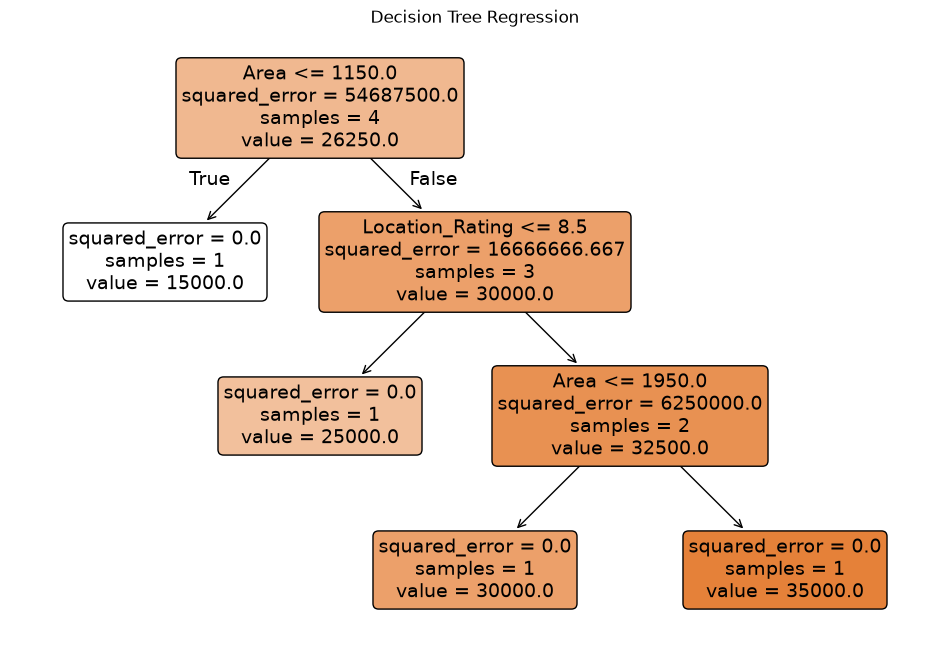

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
data = {
    'Bedrooms': [1, 2, 3, 4, 5],
    'Area': [800, 1200, 1500, 1800, 2100],
    'Location_Rating': [5, 7, 8, 9, 10],
    'Rent': [15000, 20000, 25000, 30000, 35000]
}

df = pd.DataFrame(data)

x = df[['Bedrooms', 'Area', 'Location_Rating']]
y = df['Rent']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)

reg_tree.fit(x_train,y_train)

y_pred = reg_tree.predict(x_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(12,8))

plot_tree(reg_tree, feature_names=['Bedrooms','Area','Location_Rating'], filled=True, rounded=True)

plt.title("Decision Tree Regression")
plt.show()

# Code Explanation

## Step 1

Import the required libraries.

---

## Step 2

Create a dataset containing:

- Bedrooms
- Area
- Location Rating
- Rent

---

## Step 3

Separate the features (X) and target variable (y).

---

## Step 4

Split the dataset into training and testing sets.

---

## Step 5

Train a DecisionTreeRegressor model.

The parameter max_depth=3 limits the tree depth and helps prevent overfitting.

---

## Step 6

Predict rent values for the test dataset.

---

## Step 7

Evaluate the model using:

- Mean Squared Error (MSE)
- R² Score

---

## Step 8

Visualize the Decision Tree.

Each internal node represents a decision rule.

Each leaf node represents the predicted average rent.

# Expected Output

The notebook will display:

- Mean Squared Error (MSE)
- R² Score
- Decision Tree visualization

The visualization shows:

- Internal nodes represent decision conditions.
- Branches represent possible outcomes.
- Leaf nodes contain the predicted rent value.

### Why is R² = NaN?

- The dataset contains only **5 samples**.
- With `test_size=0.2`, the test set has **only 1 sample**.
- **R² Score cannot be calculated with fewer than 2 test samples**, so it returns **NaN**.
- **MSE** is still calculated because it can be computed with a single test sample.

**Solution:** Increase the dataset size or use a larger test set (at least **2 test samples**).

Mean Squared Error: 5000000.0
R² Score: -0.25


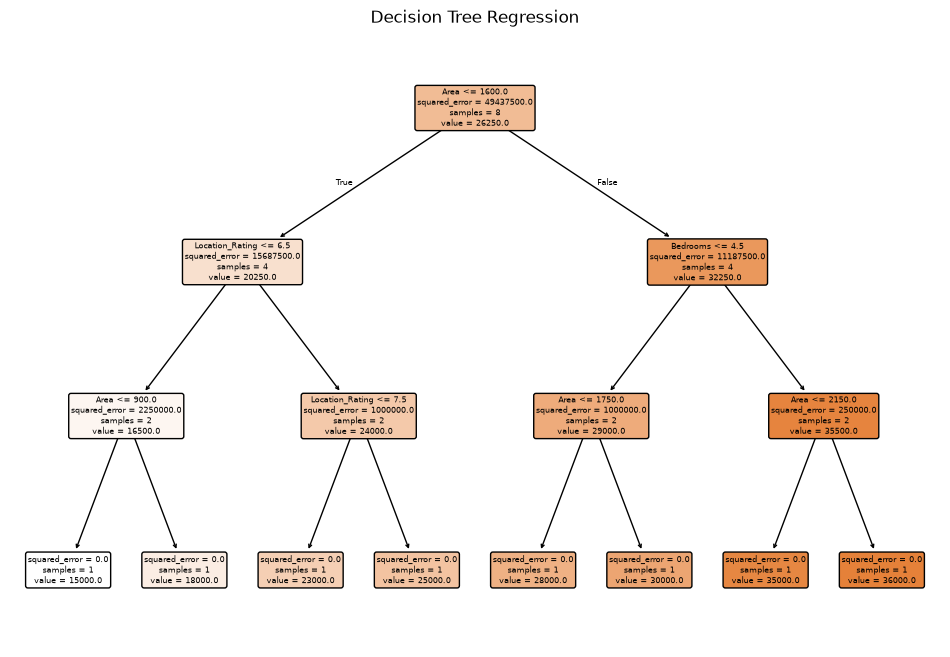

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

data = {
    'Bedrooms':[1,2,3,4,5,2,3,4,1,5],
    'Area':[800,1200,1500,1800,2100,1000,1400,1700,900,2200],
    'Location_Rating':[5,7,8,9,10,6,7,8,5,10],
    'Rent':[15000,20000,25000,30000,35000,18000,23000,28000,16000,36000]
}

df = pd.DataFrame(data)

x = df[['Bedrooms', 'Area', 'Location_Rating']]
y = df['Rent']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)

reg_tree.fit(x_train,y_train)

y_pred = reg_tree.predict(x_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(12,8))

plot_tree(reg_tree, feature_names=['Bedrooms','Area','Location_Rating'], filled=True, rounded=True)

plt.title("Decision Tree Regression")
plt.show()

---
# **Note**

Decision Trees are simple, interpretable, and powerful machine learning algorithms that can solve both classification and regression problems. Proper tuning of hyperparameters helps prevent overfitting, improves model generalization, and leads to better prediction performance.